# Validación visual de la capa silver

Después de que PySpark escribe el silver hay que confirmar que los datos siguen
teniendo sentido físico. Un pipeline puede terminar sin errores y aun así haber
perdido columnas, mezclado tipos o dejado pasar vueltas que no representan ritmo
de carrera.

La prueba elegida es la degradación de neumático: graficar tiempo de vuelta
contra vueltas de uso de la goma. Si el silver está bien, tiene que aparecer una
tendencia creciente y los tres compuestos tienen que quedar separados —el blando
arranca más rápido y se cae antes, el duro al revés—. Si el gráfico sale como una
nube sin forma, el problema está aguas arriba y no vale la pena modelar nada.

Este notebook es el paso previo a `03_ml_xgboost_estrategias.ipynb`.


## Por qué hay que filtrar antes de graficar

Dos filtros, y los dos son necesarios:

- **Ventana de tiempos.** Una vuelta bajo safety car o de entrada a boxes puede
  durar el doble que una de ritmo. Sin recortar, esos puntos estiran el eje
  vertical y aplastan la tendencia real contra el piso del gráfico. La ventana
  de 85 a 105 segundos corresponde al ritmo seco de Silverstone.
- **Compuestos de seco.** En mojado los tiempos son varios segundos más lentos.
  Esa diferencia no es degradación, es agua en la pista, y mezclarla borra la
  señal que se está buscando.

Ambos criterios reaparecen después en `src/entrenamiento_modelo.py`, ahí ya
generalizados: en vez de una ventana fija en segundos se usa la regla del 107%
sobre la mediana de cada circuito, que es lo único que funciona con 24 pistas
distintas.


INFO: Loading processed data from C:\Users\gabst\data\silver\2024_silverstone_R_silver.parquet


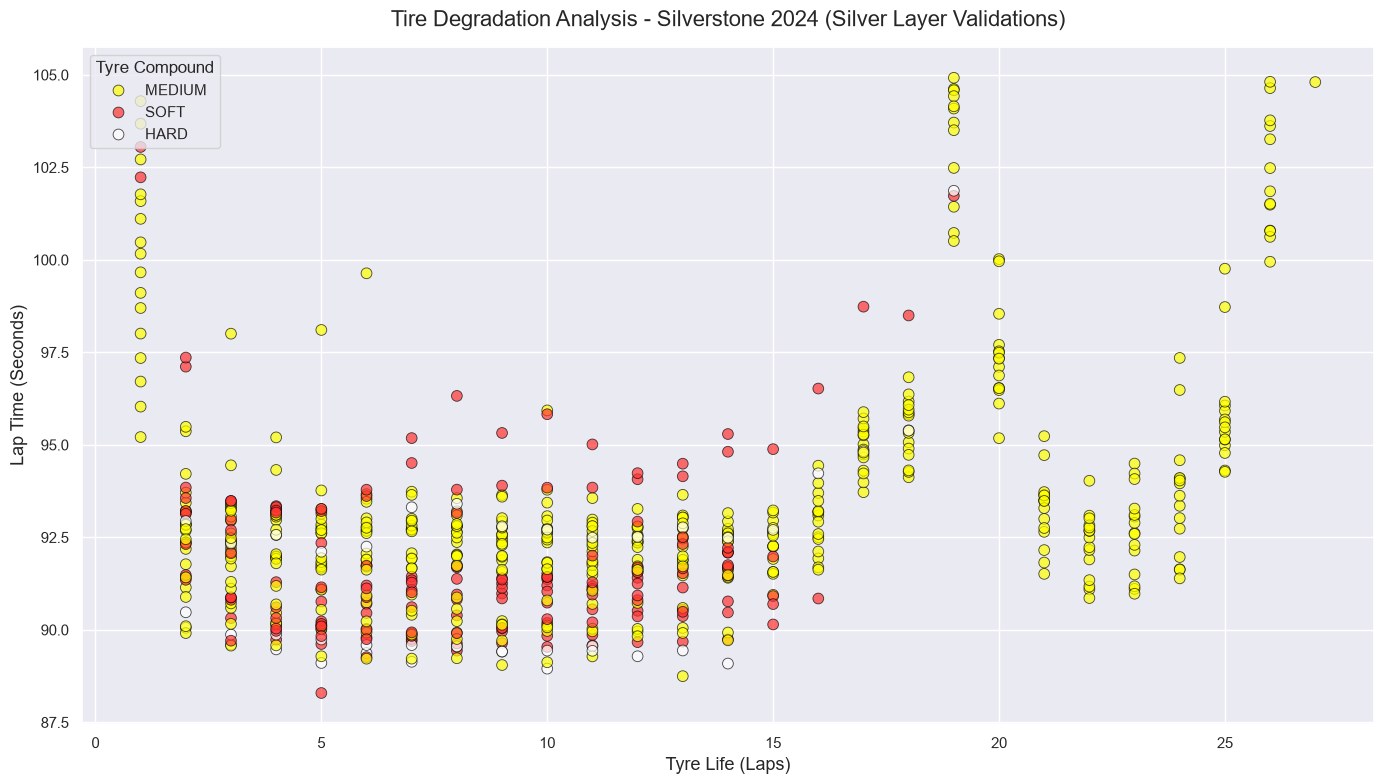

In [7]:
"""
Validación de la capa silver mediante la curva de degradación.

Lee el Parquet ya procesado y grafica tiempo de vuelta contra vida del
neumático, separando por compuesto. Es un control de calidad: si la tendencia
no aparece, hay algo mal en la transformación.
"""

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Directorio particionado que deja PySpark. Pandas lo lee como si fuera un
# único archivo gracias a pyarrow.
SILVER_DIR = r"C:\Users\gabst\data\silver\2024_silverstone_R_silver.parquet"

def plot_tyre_degradation(file_path: str):
    """
    Grafica la degradación de cada compuesto a lo largo de su vida útil.

    Cada punto es una vuelta. El eje X es cuántas vueltas lleva esa goma
    montada y el eje Y el tiempo que se tardó en darla.
    """
    print(f"INFO: Loading processed data from {file_path}")

    df_silver = pd.read_parquet(file_path)

    # Ventana de ritmo de carrera: descarta safety car, VSC y vueltas de box.
    # 85-105 s es el rango seco de Silverstone; en otro circuito habría que
    # ajustarlo, que es justamente por lo que el pipeline usa la regla del 107%.
    df_filtered = df_silver[(df_silver['LapTime'] > 85) & (df_silver['LapTime'] < 105)]

    # Solo compuestos de seco: en mojado la diferencia la marca la pista, no la goma.
    valid_compounds = ['SOFT', 'MEDIUM', 'HARD']
    df_filtered = df_filtered[df_filtered['Compound'].isin(valid_compounds)]

    # Fondo oscuro: los colores de compuesto son claros y saturados.
    sns.set_theme(style="darkgrid")

    plt.figure(figsize=(14, 8))

    sns.scatterplot(
        data=df_filtered,
        x='TyreLife',
        y='LapTime',
        hue='Compound',
        palette={'SOFT': '#FF3333', 'MEDIUM': '#FFFF00', 'HARD': '#FFFFFF'},  # colores oficiales de Pirelli
        alpha=0.7,
        s=60,
        edgecolor="black"
    )

    plt.title("Tire Degradation Analysis - Silverstone 2024 (Silver Layer Validations)", fontsize=16, pad=15)
    plt.xlabel("Tyre Life (Laps)", fontsize=13)
    plt.ylabel("Lap Time (Seconds)", fontsize=13)

    # Arriba a la izquierda queda libre: los tiempos crecen hacia la derecha.
    plt.legend(title='Tyre Compound', title_fontsize='12', loc='upper left')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_tyre_degradation(SILVER_DIR)
